In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import glob
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_score, recall_score, f1_score
import re
from sklearn.metrics import confusion_matrix
from model import SimpleSpeechCommandModel
import seaborn as sns
from data_loading import create_dataloader, COMMANDS

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class Transformer():
    pass

In [4]:
def load_model(model_path, num_classes, model_type="cnn", dropout_rate=0, **kwargs):
    if model_type == "cnn":
        model = SimpleSpeechCommandModel(num_classes=num_classes, dropout_rate=dropout_rate)
    elif model_type == "transformer":
        model = Transformer()
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

In [5]:
def evaluate_model(model, test_loader, device):
    """ Evaluates the model on a given test dataset and computes accuracy, precision, recall, and F1-score."""
    model.to(device)
    model.eval()

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    accuracy = np.mean(np.array(all_preds) == np.array(all_labels)) * 100

    precision = precision_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    recall = recall_score(all_labels, all_preds, average='macro', zero_division=1) * 100
    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=1) * 100

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1_score": f1
    }

In [6]:
def evaluate_models(model_paths, test_loader, device, model_name):
    """
    Evaluates multiple models and computes mean and standard deviation for accuracy, precision, recall, and F1-score.
    """
    metrics = {"accuracy": [], "precision": [], "recall": [], "f1_score": []}

    for model_path in model_paths:
        print(f"Evaluating {model_path} ({model_name})...")
        model = load_model(model_path, num_classes=12, model_type='cnn')
        results = evaluate_model(model, test_loader, device)

        for key in metrics.keys():
            metrics[key].append(results[key])

        print(f"Accuracy: {results['accuracy']:.2f}%, Precision: {results['precision']:.2f}%, Recall: {results['recall']:.2f}%, F1: {results['f1_score']:.2f}%")

    final_results = {metric: (np.mean(values), np.std(values, ddof=1)) for metric, values in metrics.items()}

    return final_results

In [7]:
def load_loss_data(pattern):
    """Function for loading loss"""
    csv_files = glob.glob(pattern)
    all_data = []

    for file in csv_files:
        match = re.search(r"seed_(\d+)", file)
        seed = int(match.group(1))
        df = pd.read_csv(file, names=["train_loss", "valid_loss"], header=0)
        df["epoch"] = df.index
        df["seed"] = seed
        all_data.append(df)

    df_all = pd.concat(all_data)

    df_grouped = df_all.groupby("epoch").agg(
        train_loss_mean=("train_loss", "mean"),
        train_loss_std=("train_loss", "std"),
        valid_loss_mean=("valid_loss", "mean"),
        valid_loss_std=("valid_loss", "std")
    ).reset_index()

    return df_grouped

In [8]:
def plot_loss(df, model_name, train_color, valid_color, plot_train=True, plot_valid=True):
    """
    Function for plotting loss values.

    Parameters:
    - df: DataFrame containing loss values
    - model_name: Model name printed on legend (e.g., 'Random Flipping')
    - lr: Learning rate value
    - train_color: Color for train loss
    - valid_color: Color for validation loss
    - plot_train: Whether to plot train loss (default: True)
    - plot_valid: Whether to plot validation loss (default: True)
"""
    if plot_train:
        train_label = f"Train Loss: {model_name}"
        plt.plot(df["epoch"], df["train_loss_mean"], label=train_label, color=train_color)
        plt.fill_between(df["epoch"],
                         df["train_loss_mean"] - df["train_loss_std"],
                         df["train_loss_mean"] + df["train_loss_std"],
                         color=train_color, alpha=0.2)

    if plot_valid:
        valid_label = f"Valid Loss: {model_name}"
        plt.plot(df["epoch"], df["valid_loss_mean"], label=valid_label, color=valid_color)
        plt.fill_between(df["epoch"],
                         df["valid_loss_mean"] - df["valid_loss_std"],
                         df["valid_loss_mean"] + df["valid_loss_std"],
                         color=valid_color, alpha=0.2)

In [9]:
def generate_confusion_matrix(model_type, model_path, test_loader, save_path=None):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    model = load_model(model_type, model_path)
    model = model.to(device)
    model.eval()

    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            _, predicted = torch.max(outputs, 1)

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(predicted.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    cm = confusion_matrix(all_labels, all_preds)

    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=test_loader.dataset.classes, yticklabels=test_loader.dataset.classes)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')

    if save_path:
        if save_path.endswith('.csv'):
            cm_df = pd.DataFrame(cm, index=test_loader.dataset.classes, columns=test_loader.dataset.classes)
            cm_df.to_csv(save_path, index=True)
        elif save_path.endswith('.txt'):
            np.savetxt(save_path, cm, fmt='%d', delimiter='\t')
        elif save_path.endswith('.png') or save_path.endswith('.jpg'):
            plt.savefig(save_path, dpi=300)
        else:
            print("Unsupported file extension. Supported extensions: .csv, .txt, .png, .jpg.")
            return

    plt.show()

In [10]:


data_dir = "data/train"
test_loader = create_dataloader(data_dir, batch_size=32, mode='testing')
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

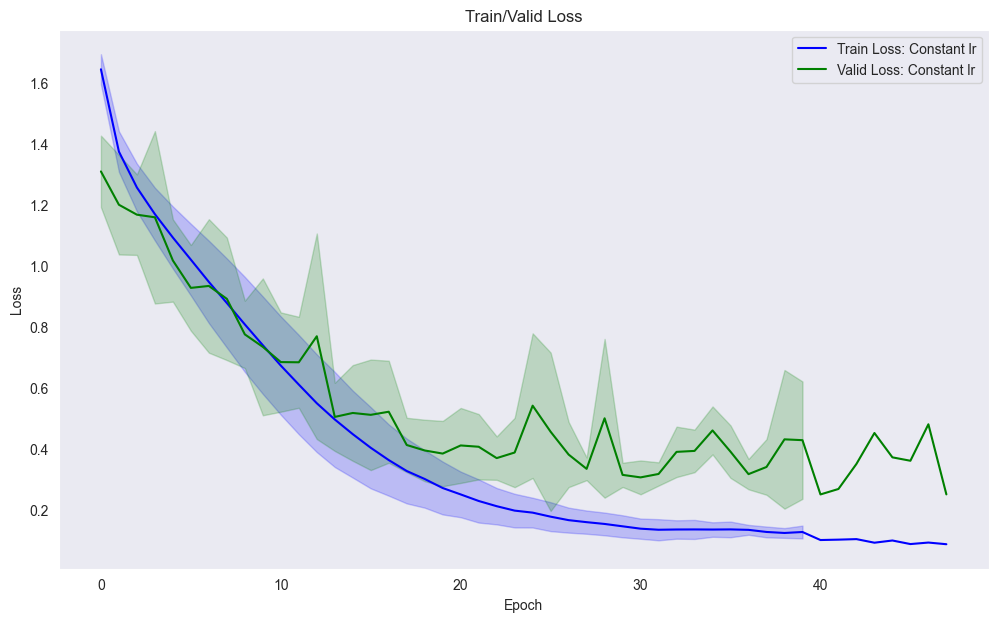

In [11]:
df_cnn = load_loss_data("saved_losses/cnn_constant_lr_0.001_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_cnn, "Constant lr", train_color="blue", valid_color="green")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Valid Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_lr_0001")
plt.show()

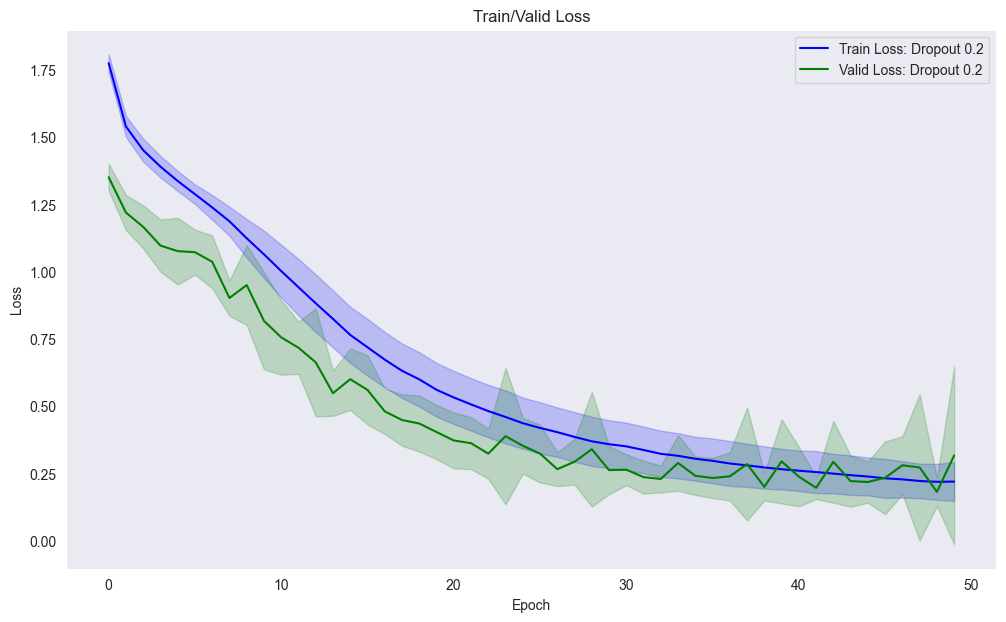

In [13]:
df_cnn = load_loss_data("saved_losses/cnn_dropout_0.2_seed_*.csv")

plt.figure(figsize=(12, 7))

plot_loss(df_cnn, "Dropout 0.2", train_color="blue", valid_color="green")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Train/Valid Loss")
plt.legend()
plt.grid()
plt.savefig("plots/cnn_lr_0001")
plt.show()

In [15]:
model_paths = {
    'Constant lr': glob.glob("saved_models/cnn_constant_lr_0.001_seed_*.pth"),
    'Dropout 0.2': glob.glob("saved_models/cnn_dropout_0.2_seed_*.pth"),
    'Dropout 0.3': glob.glob("saved_models/cnn_dropout_0.3_seed_*.pth")
}

results = {}

for model_name, paths in model_paths.items():
    results[model_name] = evaluate_models(paths, test_loader, device, model_name)

for model_name, metrics in results.items():
    print(f"\n{model_name}:")
    for metric, (mean, std) in metrics.items():
        print(f"{metric.capitalize()}: {mean:.2f}% ± {std:.2f}%")

Evaluating saved_models\cnn_constant_lr_0.001_seed_1.pth (Constant lr)...
Accuracy: 93.66%, Precision: 89.35%, Recall: 95.40%, F1: 92.17%
Evaluating saved_models\cnn_constant_lr_0.001_seed_10.pth (Constant lr)...
Accuracy: 91.39%, Precision: 86.10%, Recall: 93.64%, F1: 89.31%
Evaluating saved_models\cnn_constant_lr_0.001_seed_123.pth (Constant lr)...
Accuracy: 83.78%, Precision: 77.69%, Recall: 80.13%, F1: 77.64%
Evaluating saved_models\cnn_constant_lr_0.001_seed_2.pth (Constant lr)...
Accuracy: 91.28%, Precision: 86.28%, Recall: 92.77%, F1: 88.95%
Evaluating saved_models\cnn_constant_lr_0.001_seed_3.pth (Constant lr)...
Accuracy: 91.07%, Precision: 86.23%, Recall: 93.69%, F1: 89.38%
Evaluating saved_models\cnn_constant_lr_0.001_seed_4.pth (Constant lr)...
Accuracy: 89.38%, Precision: 82.57%, Recall: 93.30%, F1: 87.03%
Evaluating saved_models\cnn_constant_lr_0.001_seed_5.pth (Constant lr)...
Accuracy: 95.09%, Precision: 92.49%, Recall: 95.50%, F1: 93.90%
Evaluating saved_models\cnn_con

In [14]:
def compute_confusion_matrix(model, data_loader):
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in data_loader:
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    return cm

def plot_confusion_matrix(cm, class_names):
    class_names = class_names + ['silence', 'unknown']
    plt.figure(figsize=(10, 7))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

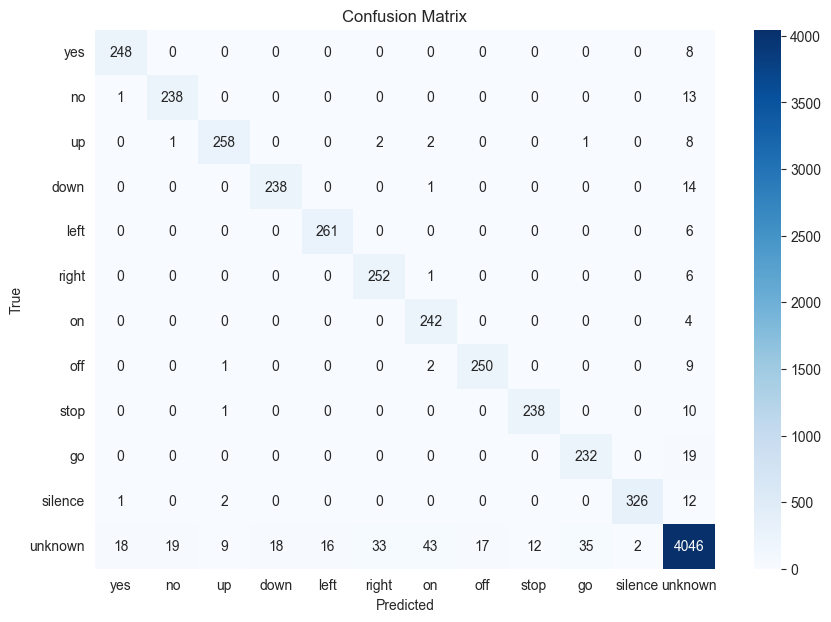

In [15]:
model_path = 'saved_models/cnn_constant_lr_0.001_seed_5.pth'
model = load_model(model_path, num_classes=12)
cm = compute_confusion_matrix(model, test_loader)
plot_confusion_matrix(cm, class_names=COMMANDS)